
========== RESULTADO ==========

Melhor rota encontrada:
[0, 1, 2, 4, 5]

Melhor custo:
8.0


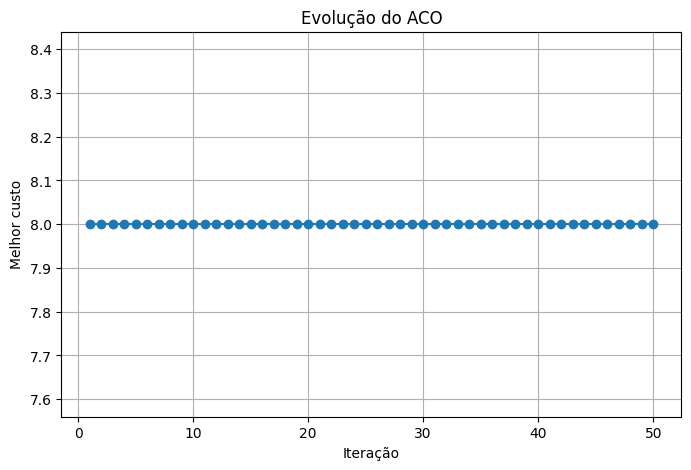

In [8]:
import numpy as np
import random
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRESENTAÇÃO DA REDE
# ============================================================

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5


# ============================================================
# 2. PARÂMETROS DO ACO
# ============================================================

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100


# ============================================================
# 3. MATRIZ DE FEROMÔNIO
# ============================================================

NUM_NOS = len(CUSTOS)

# Começamos com uma pequena quantidade de feromônio
FEROMONIO = np.ones((NUM_NOS, NUM_NOS))


# ============================================================
# FUNÇÃO: ENCONTRAR VIZINHOS VÁLIDOS
# ============================================================

def obter_vizinhos(no, visitados):
    vizinhos = []

    for proximo in range(NUM_NOS):

        # Existe ligação entre os nós?
        existe_aresta = CUSTOS[no][proximo] != np.inf

        # Não podemos visitar um nó novamente
        nao_visitado = proximo not in visitados

        if existe_aresta and nao_visitado:
            vizinhos.append(proximo)

    return vizinhos


# ============================================================
# FUNÇÃO: CONSTRUIR UMA ROTA
# ============================================================

def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        vizinhos = obter_vizinhos(atual, rota)

        # Se não houver caminho disponível, a formiga falhou
        if len(vizinhos) == 0:
            return None

        # Se o destino estiver entre os vizinhos,
        # permitimos que a formiga termine a rota.
        if DESTINO in vizinhos:
            vizinhos = [DESTINO]

        # ----------------------------------------------------
        # Calcula a probabilidade de cada próximo nó
        # ----------------------------------------------------

        probabilidades = []

        for vizinho in vizinhos:

            feromonio = FEROMONIO[atual][vizinho]
            custo = CUSTOS[atual][vizinho]

            # Heurística:
            # quanto menor o custo, maior a atratividade
            heuristica = 1 / custo

            valor = (feromonio ** ALPHA) * (heuristica ** BETA)

            probabilidades.append(valor)

        # Normaliza as probabilidades
        probabilidades = np.array(probabilidades)
        probabilidades = probabilidades / probabilidades.sum()

        # Escolhe o próximo nó de forma probabilística
        proximo = random.choices(
            vizinhos,
            weights=probabilidades,
            k=1
        )[0]

        rota.append(proximo)
        atual = proximo

    return rota


# ============================================================
# FUNÇÃO: CALCULAR O CUSTO DA ROTA
# ============================================================

def calcular_custo(rota):

    custo_total = 0

    for i in range(len(rota) - 1):

        atual = rota[i]
        proximo = rota[i + 1]

        custo_total += CUSTOS[atual][proximo]

    return custo_total


# ============================================================
# 4. ALGORITMO ACO
# ============================================================

melhor_rota_global = None
melhor_custo_global = np.inf

historico_melhor_custo = []


for iteracao in range(NUM_ITERACOES):

    rotas = []
    custos_rotas = []

    # --------------------------------------------------------
    # 5. CRIAR VÁRIAS FORMIGAS E CONSTRUIR SUAS ROTAS
    # --------------------------------------------------------

    for formiga in range(NUM_FORMIGAS):

        rota = construir_rota()

        if rota is not None:

            custo = calcular_custo(rota)

            rotas.append(rota)
            custos_rotas.append(custo)

            # Verifica se é a melhor rota encontrada até agora
            if custo < melhor_custo_global:

                melhor_custo_global = custo
                melhor_rota_global = rota.copy()

    # --------------------------------------------------------
    # 8. EVAPORAÇÃO DO FEROMÔNIO
    # --------------------------------------------------------

    FEROMONIO *= (1 - TAXA_EVAPORACAO)

    # --------------------------------------------------------
    # 7. REFORÇO DAS ROTAS
    # --------------------------------------------------------

    for rota, custo in zip(rotas, custos_rotas):

        # Quanto menor o custo, maior o reforço
        deposito = Q / custo

        for i in range(len(rota) - 1):

            atual = rota[i]
            proximo = rota[i + 1]

            FEROMONIO[atual][proximo] += deposito

    # --------------------------------------------------------
    # Guarda o melhor custo desta iteração
    # --------------------------------------------------------

    historico_melhor_custo.append(melhor_custo_global)


# ============================================================
# 10 E 11. RESULTADO FINAL
# ============================================================

print("\n========== RESULTADO ==========")

print("\nMelhor rota encontrada:")
print(melhor_rota_global)

print("\nMelhor custo:")
print(melhor_custo_global)


# ============================================================
# 12. GRÁFICO DA EVOLUÇÃO
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_ITERACOES + 1),
    historico_melhor_custo,
    marker="o"
)

plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Evolução do ACO")

plt.grid(True)

plt.show()


"""
1 - Como o feromônio ajuda o ACO a aprender quais caminhos são melhores?

O feromônio é depositado nas arestas utilizadas pelas formigas. Rotas com menor custo recebem uma quantidade maior de feromônio. Com o passar das iterações, as formigas ficam mais propensas a escolher caminhos que possuem mais feromônio, fazendo o algoritmo aprender quais caminhos apresentam melhores resultados.

2 - Diferença entre explorar e aproveitar caminhos

Explorar significa experimentar caminhos diferentes para descobrir novas possibilidades. Aproveitar significa continuar escolhendo caminhos que já apresentaram bons resultados. O ACO precisa equilibrar os dois: explorar para não ficar preso em uma solução ruim e aproveitar para melhorar soluções que já se mostraram boas.

3 - Como melhorar o desempenho em uma rede muito maior?

Eu investigaria primeiro a quantidade de formigas e o número de iterações, pois eles determinam diretamente quantas rotas serão calculadas. Em uma rede muito grande, testar muitas formigas durante muitas iterações pode aumentar bastante o tempo de execução. Também seria interessante otimizar a construção das rotas e limitar a busca a vizinhos promissores.
"""